# Power Dominating Set — Research Notebook
**Dataset:** Harwell-Boeing BCSPWR Collection  
**Goal:** Implement and evaluate a Greedy Heuristic for PDS, compare with ILP optimal

## Section 1 — Imports & Setup

In [1]:
%pip install pandapower

Note: you may need to restart the kernel to use updated packages.


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd
from scipy.io import mmread
import random
import networkx as nx
from collections import defaultdict
import pandapower.networks as nw
import pandapower.topology as top
import gzip
import scipy.io




print("All libraries loaded successfully. trying")

All libraries loaded successfully. trying


## Section 2 — Load a Single Graph

In [3]:
def load_graph(filepath):
    """
    Load a graph from a Matrix Market (.mtx or .mtx.gz) file.
    Removes self-loops since they are irrelevant to PDS.
    """
    A = mmread(filepath)
    G = nx.from_scipy_sparse_array(A)
    G.remove_edges_from(nx.selfloop_edges(G))
    return G


# Load BCSPWR01 as a test
G = load_graph("datasets/bcspwr01.mtx.gz")

print(f"Nodes         : {G.number_of_nodes()}")
print(f"Edges         : {G.number_of_edges()}")
print(f"Avg degree    : {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"Max degree    : {max(G.degree(), key=lambda x: x[1])}")

Nodes         : 39
Edges         : 46
Avg degree    : 2.36
Max degree    : (15, 5)


/tmp/ipykernel_10548/3637682648.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


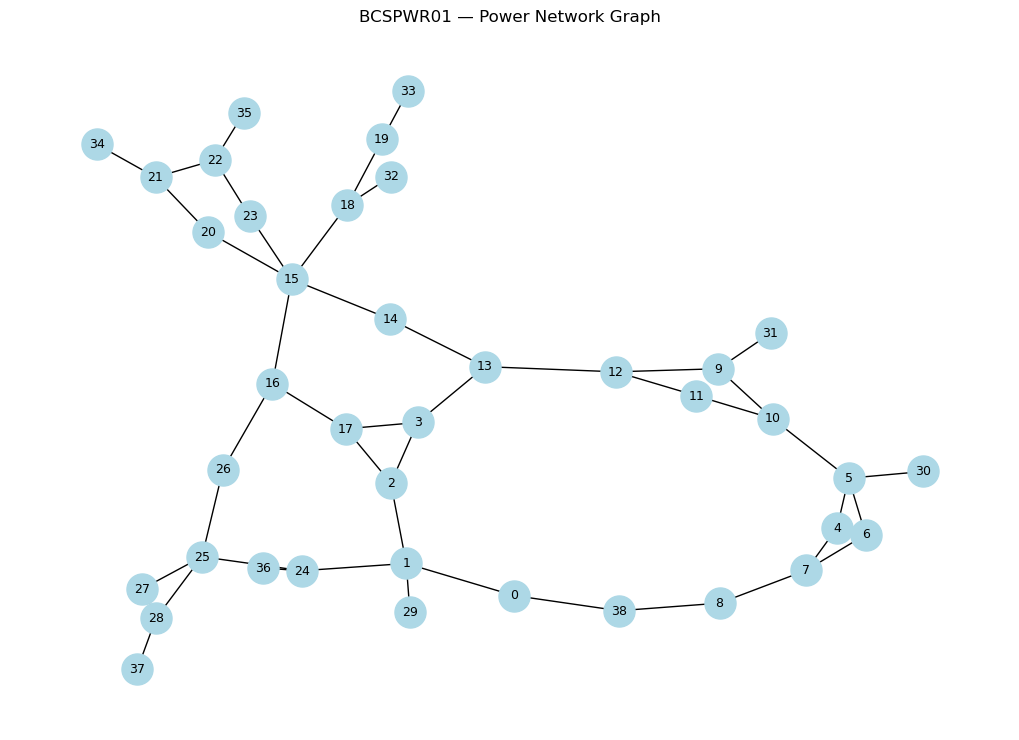

In [4]:
# Visualize the graph
plt.figure(figsize=(10, 7))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, font_size=9)
plt.title("BCSPWR01 — Power Network Graph")
plt.tight_layout()
plt.show()

## Section 3: 
**PDS Rules:**
- **Rule 1 (Domination):** If node `v` is in PDS, then `v` and all its neighbors are observed.
- **Rule 2 (Propagation):** If an observed node `v` has exactly one unobserved neighbor, that neighbor becomes observed.


In [5]:
from collections import deque

def propagate(G, observed):
    """Apply PDS Rule 2 to a fixpoint, in-place. Worklist version."""
    adj = G.adj
    # how many unobserved neighbors each vertex currently has
    unmon = {v: sum(1 for w in adj[v] if w not in observed) for v in G.nodes()}
    # observed vertices that can force right now (exactly one unobserved neighbor)
    q = deque(v for v in observed if unmon[v] == 1)

    while q:
        v = q.popleft()
        if v not in observed or unmon[v] != 1:   # stale entry, skip
            continue
        w = next(x for x in adj[v] if x not in observed)   # its one unobserved neighbor
        observed.add(w)
        # only w's neighbors change; update just them
        for x in adj[w]:
            unmon[x] -= 1
            if x in observed and unmon[x] == 1:
                q.append(x)
        if unmon[w] == 1:        # w itself may now be able to force
            q.append(w)

## Section 3:
### H1: Greedy Candidate Selection by Degree
At each iteration, the node with the highest degree (most neighbors) is selected from the remaining candidates — those not yet in the PDS.

In [6]:
def h1_greedy_pds(G, k=1, seed=None):
    if seed is not None: random.seed(seed)
    observed, pds = set(), set()
    all_nodes = set(G.nodes())

    # degree is static, so rank once
    ranked = sorted(all_nodes, key=lambda v: G.degree(v), reverse=True)

    while observed != all_nodes:
        # skip already-picked nodes, keep the top-k still available
        candidates = [v for v in ranked if v not in pds][:k]
        best = random.choice(candidates)

        pds.add(best)
        observed.add(best)
        observed.update(G.neighbors(best))
        propagate(G, observed)

    return pds

## Section 4:
### H2: Greedy Candidate Selection by Effective Degree
At each iteration, the node with the highest effective degree — the number of currently unobserved neighbors — is selected from the remaining candidates as the next node to add to the PDS.

In [7]:
def h2_effective_greedy_pds(G, k=1, seed=None):
    if seed is not None: random.seed(seed)
    observed, pds = set(), set()
    remaining = set(G.nodes())
    all_nodes = set(G.nodes())

    while observed != all_nodes:
        scored = sorted(remaining,
                        key=lambda v: len(set(G.neighbors(v)) - observed),
                        reverse=True)
        best = random.choice(scored[:k])

        pds.add(best)
        remaining.discard(best)
        observed.add(best)
        observed.update(G.neighbors(best))
        propagate(G, observed)

    return pds

## Section 5:
### H3: Multi-Hop Weighted Greedy Heuristic for PDS

**Greedy Strategy (multi-hop):**
Instead of scoring a candidate node by only its *immediate* degree (neighbors at distance 1), score it using neighbors at distance 1, 2, and 3:

- `d1(v)` = number of nodes at **exactly distance 1** (primary neighbors)
- `d2(v)` = number of nodes at **exactly distance 2** (secondary neighbors)
- `d3(v)` = number of nodes at **exactly distance 3** (tertiary neighbors)

Weighted score:

$$\text{score}(v) = w_1 \cdot d_1(v) + w_2 \cdot d_2(v) + w_3 \cdot d_3(v)$$

At each step, pick the node with the **highest weighted score**, then apply Rule 1 and Rule 2.

**Intuition:** Basic greedy is myopic — it only considers the immediate degree. Multi-hop scoring is more far-sighted: a node that also covers many distance-2 and distance-3 neighbors is a better long-term choice, especially given how propagation (Rule 2) can chain through the graph.

In [17]:
def compute_multihop_score_basic(G, v, w1=1.0, w2=0.5, w3=0.25):
    """
    Compute weighted multi-hop score for node v.

    d1 = # nodes at exactly distance 1 from v (primary)
    d2 = # nodes at exactly distance 2 from v (secondary)
    d3 = # nodes at exactly distance 3 from v (tertiary)

    score = w1*d1 + w2*d2 + w3*d3
    """
    visited = {v}

    # Distance 1
    level1 = set(G.neighbors(v)) - visited
    visited.update(level1)
    d1 = len(level1)

    # Distance 2
    level2 = set()
    for u in level1:
        level2.update(G.neighbors(u))
    level2 -= visited
    visited.update(level2)
    d2 = len(level2)

    # Distance 3
    level3 = set()
    for u in level2:
        level3.update(G.neighbors(u))
    level3 -= visited
    d3 = len(level3)

    return w1 * d1 + w2 * d2 + w3 * d3


def h3_greedy_multihop_pds(G, w1=1.0, w2=0.5, w3=0.25, k=1, seed=None):
    if seed is not None: random.seed(seed)
    observed, pds = set(), set()
    all_nodes = set(G.nodes())

    # multi-hop score is static, so rank once
    ranked = sorted(all_nodes,
                    key=lambda v: compute_multihop_score_basic(G, v, w1, w2, w3),
                    reverse=True)

    while observed != all_nodes:
        candidates = [v for v in ranked if v not in pds][:k]
        best = random.choice(candidates)

        pds.add(best)
        observed.add(best)
        observed.update(G.neighbors(best))
        propagate(G, observed)

    return pds

## Section 6: 
### H4: Weighted Multi-Hop Effective Degree Greedy Heuristic for PDS

**Greedy Strategy (multi-hop):**
Instead of scoring a candidate node by only its *immediate* unobserved neighbors (basic greedy), score it using neighbors at distance 1, 2, and 3:

- `d1(v)` = number of unobserved nodes at **exactly distance 1** (primary neighbors)
- `d2(v)` = number of unobserved nodes at **exactly distance 2** (secondary neighbors)
- `d3(v)` = number of unobserved nodes at **exactly distance 3** (tertiary neighbors)

Weighted score:

$$\text{score}(v) = w_1 \cdot d_1(v) + w_2 \cdot d_2(v) + w_3 \cdot d_3(v)$$


In [8]:
def compute_multihop_score_effective(G, v, observed, w1=1.0, w2=0.5, w3=0.25):
    """
    Compute weighted multi-hop score for node v.

    d1 = # unobserved nodes at exactly distance 1 from v (primary)
    d2 = # unobserved nodes at exactly distance 2 from v (secondary)
    d3 = # unobserved nodes at exactly distance 3 from v (tertiary)

    score = w1*d1 + w2*d2 + w3*d3
    """
    visited = {v}

    # Distance 1
    level1 = set(G.neighbors(v)) - visited
    visited.update(level1)
    d1 = len(level1 - observed)

    # Distance 2
    level2 = set()
    for u in level1:
        level2.update(G.neighbors(u))
    level2 -= visited
    visited.update(level2)
    d2 = len(level2 - observed)

    # Distance 3
    level3 = set()
    for u in level2:
        level3.update(G.neighbors(u))
    level3 -= visited
    d3 = len(level3 - observed)

    return w1 * d1 + w2 * d2 + w3 * d3

def h4_effective_greedy_multihop_pds(G, w1=1.0, w2=0.5, w3=0.25, k=1, seed=None):
    if seed is not None: random.seed(seed)
    observed, pds = set(), set()
    remaining = set(G.nodes())
    all_nodes = set(G.nodes())

    while observed != all_nodes:
        scored = sorted(remaining,
                        key=lambda v: compute_multihop_score_effective(G, v, observed, w1, w2, w3),
                        reverse=True)
        best = random.choice(scored[:k])

        pds.add(best)
        remaining.discard(best)
        observed.add(best)
        observed.update(G.neighbors(best))
        propagate(G, observed)

    return pds

## Section 7: Near twin based greedy

Two **adjacent** vertices whose neighborhoods are almost identical.

Vertices `u` and `v` are near twins if they are adjacent and:

`|(N(u) \ {v}) △ (N(v) \ {u})| ≤ ε`

i.e. their neighborhoods (excluding each other) differ by at most `ε` vertices.

- `ε = 0` → **exact twins** (identical neighbors)
- larger `ε` → looser similarity

Near twins occupy nearly the same structural position, suggesting redundancy in domination problems. 

In [9]:
def true_near_twins_per_vertex(G, epsilon=1):
    """
    TRUE near-twin pairs: u ~ v (ADJACENT) and
        0 < |(N(u)-{v}) Δ (N(v)-{u})| <= epsilon
    (neighborhoods compared while ignoring each other)
    Returns dict: node -> list of (other_node, sym_diff_size)
    """
    nbhd = {v: frozenset(G.neighbors(v)) for v in G.nodes()}
    near_twin = {v: [] for v in G.nodes()}

    for u in G.nodes():
        for v in G.neighbors(u):          # true twins are adjacent
            if v <= u:                    # each pair once
                continue
            sd = len((nbhd[u] - {v}) ^ (nbhd[v] - {u}))
            if 0 < sd <= epsilon:
                near_twin[u].append((v, sd))
                near_twin[v].append((u, sd))

    for v in near_twin:
        near_twin[v].sort(key=lambda x: x[1])
    return near_twin

### H5: Twin-Guided Greedy Heuristic

A two-phase heuristic that prioritizes structurally redundant vertices (near twins) before falling back to standard degree-based greedy.

**Phase 1 — Twin-first selection.**
Among all vertices that have at least one near twin, repeatedly select the highest-degree candidate, mark its closed neighborhood as observed, and propagate. The phase continues until no near twins remain, or until no remaining twin contributes any newly observed vertex.

**Phase 2 — Degree-based greedy.**
Select the highest-degree remaining vertex, observe its closed neighborhood, and propagate. Repeat until the entire graph is observed.

The intuition is that near twins occupy nearly identical structural positions, so seeding the solution with them first may capture redundant regions early. The effectiveness of this approach is expected to depend on graph structure: on graphs rich in near twins or dense local clusters, twin-first selection may yield more compact solutions, whereas on sparse graphs with little twin structure it tends to reduce to plain degree-based greedy.

In [10]:
def h5_twin_guided_greedy(G, epsilon=1, k=1, seed=None):
    """
    Twin-first, degree-based power-dominating-set heuristic.

    Phase 1: pick the highest-degree near-twin, observe + propagate.
             Repeat until no twin is left (or none helps anymore).
    Phase 2: pick the highest-degree remaining vertex, observe + propagate,
             until the whole graph is observed.
    """
    if seed is not None:
        random.seed(seed)

    observed, pds = set(), set()
    all_nodes = set(G.nodes())
    deg = dict(G.degree())                       # raw degree, fixed once

    near_twin = true_near_twins_per_vertex(G, epsilon=epsilon)
    remaining_twins = {v for v, lst in near_twin.items() if lst}

    def gain(v):                                 # new vertices v would observe
        return len((set(G.neighbors(v)) | {v}) - observed)

    def pick(cands, key):                        # highest key, top-k random
        scored = sorted(cands, key=key, reverse=True)
        return random.choice(scored[:k]) if k > 1 else scored[0]

    def commit(v):
        pds.add(v)
        observed.add(v)
        observed.update(G.neighbors(v))
        propagate(G, observed)

    # --- Phase 1: twins first, highest degree ---
    while observed != all_nodes and remaining_twins:
        best = pick(remaining_twins, key=lambda v: deg[v])
        if gain(best) == 0:                      # no twin adds anything new
            break
        commit(best)
        remaining_twins = {v for v in remaining_twins
                           if v not in pds and gain(v) > 0}

    # --- Phase 2: degree-based greedy ---
    remaining = all_nodes - pds
    while observed != all_nodes:
        best = pick(remaining, key=lambda v: deg[v])
        commit(best)
        remaining.discard(best)

    return pds

## Section 8: Post-Processing

The greedy and multi-hop heuristics build a power dominating set incrementally, adding one vertex at a time until the entire graph is observed. This construction is **monotone** — a vertex is never reconsidered once placed — which means the final set can contain vertices that later became redundant as propagation spread observation across the graph. Such a set is valid, but not necessarily minimal.

**Pruning** is a post-processing step that removes this redundancy. After a valid PDS is constructed, we test whether individual vertices can be dropped while still observing the whole graph. A vertex is redundant if the set remains a valid PDS without it; redundant vertices are removed, yielding a smaller (minimal) solution without changing validity.

This matters because PDS quality is measured by *size* — fewer vertices means fewer PMUs to place, which is the actual objective. Pruning lets the construction heuristic stay simple and fast (it need not avoid redundancy on the fly), while a separate, cleaner pass tightens the result. We consider two pruning strategies: a naive single-pass remover that re-checks observation for every candidate, and a fort-based pruner that avoids many of these expensive checks by caching the structural obstructions (forts) that force certain vertices to remain.

### Section 8.1: Naive Pruning

The simplest pruning strategy: test each vertex in the PDS once, and remove it if the rest of the set still observes the whole graph.

For every vertex `s` in the solution, recompute the observation closure on `S \ {s}`. If the graph remains fully observed, `s` is redundant and is dropped; otherwise it is kept. Each test costs one full closure computation.


In [11]:
from collections import deque

def fast_monitored(G, S):
    """Domination + zero-forcing closure, worklist-based. Returns the observed set."""
    adj = G.adj
    monitored = set()
    for s in S:
        monitored.add(s); monitored.update(adj[s])
    unmon = {v: sum(1 for w in adj[v] if w not in monitored) for v in G.nodes()}
    q = deque(v for v in monitored if unmon[v] == 1)
    while q:
        v = q.popleft()
        if v not in monitored or unmon[v] != 1:
            continue
        w = next((x for x in adj[v] if x not in monitored), None)
        if w is None:
            continue
        monitored.add(w)
        for x in adj[w]:
            unmon[x] -= 1
            if x in monitored and unmon[x] == 1:
                q.append(x)
        if unmon[w] == 1:
            q.append(w)
    return monitored


In [12]:
def naive_prune(G, pds, order=None):
    all_nodes = set(G.nodes())
    S = set(pds)
    candidates = list(order) if order is not None else list(S)
    n_closures = 0
    changed = True
    while changed:
        changed = False
        for s in candidates:
            if s not in S:
                continue
            n_closures += 1
            if fast_monitored(G, S - {s}) == all_nodes:   # everything still covered?
                S.discard(s); changed = True
    return S, n_closures

### Section 8.2: Fort-Based Pruning

Each vertex in the solution set is tested for removal. To test a vertex `v`, the closure is computed on `S - {v}`, giving an observed set `M`. If `M == all_nodes`, then `v` is redundant and can be excluded from the solution. Otherwise, `v` is kept.

When `v` is kept, the unobserved remainder `W = all_nodes - M` forms a **fort**. This fort is stored along with its closed neighborhood `closed_nbhd(G, W)` — every vertex that touches the fort.

The cached forts are used to save computation. Before running a full closure for a vertex `s`, the cache is checked first: if `(NF & S) == {s}` for any cached fort — meaning `s` is the only solution vertex touching that fort — then `s` cannot be removed, since dropping it would leave the fort unobserved. In this case `s` is locked immediately and the expensive closure is skipped, avoiding a full recomputation over the graph.

In [13]:
def closed_nbhd(G, F):
    NF = set(F)
    for v in F: NF.update(G.neighbors(v))
    return NF

def fort_prune(G, pds, order=None, verify=True):
    """Prune a valid PDS to a minimal one using forts. Returns (S, n_closures)."""
    all_nodes = set(G.nodes())
    S = set(pds)
    cache = []                          # forts discovered along the way
    if verify:
        assert fast_monitored(G, S) == all_nodes, "input is not a valid PDS"

    locked = set()
    candidates = list(order) if order is not None else list(S)
    n_closures = 0

    changed = True
    while changed:
        changed = False
        for s in candidates:
            if s not in S or s in locked:
                continue
            if any((NF & S) == {s} for (_, NF) in cache):   # cheap: sole cover of a cached fort
                locked.add(s)
                continue
            n_closures += 1                                  # expensive: full closure without s
            M = fast_monitored(G, S - {s})
            if M == all_nodes:
                S.discard(s); changed = True                 # s was redundant
            else:
                W = frozenset(all_nodes - M)                 # stall remainder = a new fort
                cache.append((W, frozenset(closed_nbhd(G, W))))
                locked.add(s)
    return S, n_closures

## Section 9: Run all heuristic Greedily

Always pick the best vertex

In [14]:
datasets = [
    ("BCSPWR01", "mtx", "datasets/bcspwr01.mtx.gz"),
    ("BCSPWR02", "mtx", "datasets/bcspwr02.mtx.gz"),
    ("BCSPWR03", "mtx", "datasets/bcspwr03.mtx.gz"),
    ("BCSPWR04", "mtx", "datasets/bcspwr04.mtx.gz"),
    ("BCSPWR05", "mtx", "datasets/bcspwr05.mtx.gz"),
    ("BCSPWR06", "mtx", "datasets/bcspwr06.mtx.gz"),
    ("BCSPWR07", "mtx", "datasets/bcspwr07.mtx.gz"),
    ("BCSPWR08", "mtx", "datasets/bcspwr08.mtx.gz"),
    ("BCSPWR09", "mtx", "datasets/bcspwr09.mtx.gz"),
    ("BCSPWR10", "mtx", "datasets/bcspwr10.mtx.gz"),

    ("494_bus",  "mtx", "datasets/494_bus.mtx.gz"),
    ("662_bus",  "mtx", "datasets/662_bus.mtx.gz"),
    ("685_bus",  "mtx", "datasets/685_bus.mtx.gz"),
    ("1138_bus", "mtx", "datasets/1138_bus.mtx.gz"),

    ("IEEE14",   "pp", "case14"),
    ("IEEE30",   "pp", "case30"),
    ("IEEE57",   "pp", "case57"),
    ("IEEE118",  "pp", "case118"),
    ("IEEE300",  "pp", "case300"),

    ("illinois200", "pp", "case_illinois200"),
    ("pegase1354",  "pp", "case1354pegase"),
    ("pegase2869",  "pp", "case2869pegase"),
    ("pegase9241",  "pp", "case9241pegase"),

    ("case1888rte", "pp", "case1888rte"),
    ("case2848rte", "pp", "case2848rte"),
    ("case6470rte", "pp", "case6470rte"),

    ("case1951rte", "ptxt", "datasets/case1951rte.ptxt"),
    ("case2868rte", "ptxt", "datasets/case2868rte.ptxt"),
    ("case6468rte", "ptxt", "datasets/case6468rte.ptxt"),
]

results = []

In [15]:
def load_mtx_gz(path):
    with gzip.open(path, 'rt') as f:
        matrix = scipy.io.mmread(f)
    G = nx.from_scipy_sparse_array(matrix)
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

def load_pandapower(case_name, largest_cc=False):
    net = getattr(nw, case_name)()
    G = top.create_nxgraph(net, respect_switches=False, multi=False)
    G = nx.Graph(G)                            # simple, undirected
    G.remove_edges_from(nx.selfloop_edges(G))  # same cleanup as your mtx loader
    if largest_cc:
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        G = nx.relabel_nodes(G, {old: i for i, old in enumerate(sorted(G.nodes()))})
    return G

def load_ptxt(path):
    """Parse Bläsius-Göttlicher .ptxt adjacency format into a NetworkX graph.

    Format: 'Number Of Vertices' / <n> / 'Edges' then, per node k:
        'Number edges containting node k' / <deg> / 'list' / <deg neighbor ids>
    Header/text lines are ignored; we read the integers in order.
    """
    # collect every integer in the file, in order
    nums = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.isdigit():            # a pure-number line
                nums.append(int(line))
            else:
                # some 'list' lines may hold several space-separated ids
                parts = line.split()
                if parts and all(p.isdigit() for p in parts):
                    nums.extend(int(p) for p in parts)

    i = 0
    n = nums[i]; i += 1                   # number of vertices
    G = nx.Graph()
    G.add_nodes_from(range(n))

    node = 0
    while i < len(nums) and node < n:
        deg = nums[i]; i += 1             # degree of this node
        for _ in range(deg):
            nbr = nums[i]; i += 1
            G.add_edge(node, nbr)         # all-propagating: just take edges
        node += 1

    G.remove_edges_from(nx.selfloop_edges(G))
    return G

In [ ]:
import time
import pandas as pd

results = []
raw_pds = {}    # {name: {h: PDS set}}  -- pruning cell will reuse these
graphs  = {}    # {name: G}            -- pruning needs the graph too

heuristics = {
    "H1": h1_greedy_pds,
    "H2": h2_effective_greedy_pds,
    "H3": h3_greedy_multihop_pds,
    "H4": h4_effective_greedy_multihop_pds,
    "H5": h5_twin_guided_greedy,
}

for name, kind, source in datasets:
    if kind == "mtx":
        G = load_mtx_gz(source)
    elif kind == "ptxt":
        G = load_ptxt(source)
    else:
        G = load_pandapower(source, largest_cc=True)

    n, m = G.number_of_nodes(), G.number_of_edges()
    row = {"Dataset": name, "Nodes": n, "Edges": m}

    graphs[name]  = G            # cache graph
    raw_pds[name] = {}           # store this instance's PDS sets

    for h, fn in heuristics.items():
        t0 = time.perf_counter()          # start timing
        pds = fn(G)
        t1 = time.perf_counter()          # end timing
        raw_pds[name][h] = pds            # keep the actual set, not just length
        row[h] = len(pds)                 # PDS size
        row[f"{h}_time"] = round(t1 - t0, 4)   # seconds, 4 decimals

    results.append(row)
    print(f"{name}: n={n}, m={m} | " +
          " ".join(f"{h}={row[h]}({row[f'{h}_time']}s)" for h in heuristics))

df = pd.DataFrame(results)
print()
print(df.to_string(index=False))

df.to_csv("results/size_timing_results.csv", index=False)   # save to CSV
print("\nsaved -> size_timing_results.csv")

# ---- persist PDS sets + graphs to disk so pruning never recomputes them ----
import pickle
pickle.dump(raw_pds, open("raw_pds.pkl", "wb"))
print("saved -> raw_pds.pkl")

BCSPWR01: n=39, m=46 | H1=14(0.0012s) H2=6(0.0005s) H3=16(0.0012s) H4=8(0.0017s) H5=10(0.0005s)
BCSPWR02: n=49, m=59 | H1=11(0.0008s) H2=6(0.0007s) H3=30(0.002s) H4=8(0.0028s) H5=13(0.001s)
BCSPWR03: n=118, m=179 | H1=32(0.0031s) H2=10(0.002s) H3=70(0.0091s) H4=11(0.0111s) H5=37(0.0043s)
BCSPWR04: n=274, m=669 | H1=168(0.0407s) H2=26(0.0101s) H3=242(0.0596s) H4=35(0.1174s) H5=171(0.048s)
BCSPWR05: n=443, m=590 | H1=191(0.0862s) H2=54(0.0332s) H3=367(0.134s) H4=67(0.2575s) H5=206(0.1196s)
BCSPWR06: n=1454, m=1923 | H1=632(0.8553s) H2=158(0.2798s) H3=1071(1.1889s) H4=183(1.644s) H5=622(0.7365s)
BCSPWR07: n=1612, m=2106 | H1=686(0.8942s) H2=187(0.3753s) H3=1368(1.7031s) H4=219(2.1634s) H5=733(0.9897s)
BCSPWR08: n=1624, m=2213 | H1=731(0.9312s) H2=180(0.3701s) H3=1418(1.7864s) H4=209(2.5506s) H5=723(1.1633s)
BCSPWR09: n=1723, m=2394 | H1=519(0.82s) H2=188(0.4968s) H3=1523(2.2029s) H4=233(3.3001s) H5=573(0.9307s)
BCSPWR10: n=5300, m=8271 | H1=2275(12.6923s) H2=366(3.2481s) H3=4465(24.9369s)

### Section 9.1: Run naive pruning on all heuristic

In [ ]:
import gzip
import scipy.io
import networkx as nx
import pandas as pd
import time
import pickle

raw_pds = pickle.load(open("raw_pds.pkl", "rb"))

heuristics = {
    "H1": h1_greedy_pds,
    "H2": h2_effective_greedy_pds,
    "H3": h3_greedy_multihop_pds,
    "H4": h4_effective_greedy_multihop_pds,
    "H5": h5_twin_guided_greedy,
}

results = []

for name, kind, source in datasets:
    if kind == "mtx":
        G = load_mtx_gz(source)
    elif kind == "ptxt":
        G = load_ptxt(source)
    else:
        G = load_pandapower(source, largest_cc=True)

    n, m = G.number_of_nodes(), G.number_of_edges()
    row = {"Dataset": name, "Nodes": n, "Edges": m}

    for h_name in heuristics:
        pds = raw_pds[name][h_name]            # reuse saved set, no rebuild

        t0 = time.perf_counter()               # time the pruning only
        pruned, n_closures = naive_prune(G, pds)
        t1 = time.perf_counter()

        row[f"{h_name}_raw"]     = len(pds)
        row[f"{h_name}_pruned"]  = len(pruned)
        row[f"{h_name}_time"]    = round(t1 - t0, 4)   # seconds
        row[f"{h_name}_closures"] = n_closures

    results.append(row)
    print(f"{name}: " +
          " | ".join(f"{h}={row[f'{h}_raw']}->{row[f'{h}_pruned']} "
                     f"({row[f'{h}_time']}s)"
                     for h in heuristics))

df = pd.DataFrame(results)
print()
print(df.to_string(index=False))

df.to_csv("results/naive_prune_results.csv", index=False)
print("\nsaved -> naive_prune_results.csv")

BCSPWR01: H1=14->5 (0.0024s) | H2=6->5 (0.0015s) | H3=16->6 (0.0034s) | H4=8->5 (0.0019s) | H5=10->5 (0.002s)
BCSPWR02: H1=11->6 (0.0028s) | H2=6->6 (0.0009s) | H3=30->7 (0.0052s) | H4=8->6 (0.0019s) | H5=13->6 (0.0028s)
BCSPWR03: H1=32->9 (0.0137s) | H2=10->10 (0.0019s) | H3=70->9 (0.0164s) | H4=11->8 (0.0046s) | H5=37->9 (0.0104s)
BCSPWR04: H1=168->25 (0.0871s) | H2=26->24 (0.0263s) | H3=242->32 (0.1501s) | H4=35->24 (0.0332s) | H5=171->25 (0.0887s)
BCSPWR05: H1=191->53 (0.1929s) | H2=54->48 (0.0975s) | H3=367->65 (0.3799s) | H4=67->49 (0.1099s) | H5=206->55 (0.2137s)
BCSPWR06: H1=632->151 (2.8319s) | H2=158->144 (0.8994s) | H3=1071->185 (3.3709s) | H4=183->146 (0.9303s) | H5=622->154 (1.967s)
BCSPWR07: H1=686->174 (2.4862s) | H2=187->167 (1.1233s) | H3=1368->245 (5.4583s) | H4=219->174 (1.2035s) | H5=733->178 (2.7469s)
BCSPWR08: H1=731->178 (2.8736s) | H2=180->165 (1.0837s) | H3=1418->248 (4.9887s) | H4=209->171 (1.1977s) | H5=723->178 (2.5495s)
BCSPWR09: H1=519->174 (2.1026s) | H2=

### Section 9.2: Run fort based pruning on all heuristic


In [ ]:
import gzip
import scipy.io
import networkx as nx
import pandas as pd
import time
import pickle

raw_pds = pickle.load(open("raw_pds.pkl", "rb"))

heuristics = {
    "H1": h1_greedy_pds,
    "H2": h2_effective_greedy_pds,
    "H3": h3_greedy_multihop_pds,
    "H4": h4_effective_greedy_multihop_pds,
    "H5": h5_twin_guided_greedy,
}

results = []

for name, kind, source in datasets:
    if kind == "mtx":
        G = load_mtx_gz(source)
    elif kind == "ptxt":
        G = load_ptxt(source)
    else:
        G = load_pandapower(source, largest_cc=True)

    n, m = G.number_of_nodes(), G.number_of_edges()
    row = {"Dataset": name, "Nodes": n, "Edges": m}

    for h_name in heuristics:
        pds = raw_pds[name][h_name]            # reuse saved set, no rebuild

        t0 = time.perf_counter()               # time the fort pruning only
        pruned, n_closures = fort_prune(G, pds)
        t1 = time.perf_counter()

        row[f"{h_name}_raw"]      = len(pds)
        row[f"{h_name}_pruned"]   = len(pruned)
        row[f"{h_name}_time"]     = round(t1 - t0, 4)   # seconds
        row[f"{h_name}_closures"] = n_closures

    results.append(row)
    print(f"{name}: " +
          " | ".join(f"{h}={row[f'{h}_raw']}->{row[f'{h}_pruned']} "
                     f"({row[f'{h}_time']}s)"
                     for h in heuristics))

df = pd.DataFrame(results)
print()
print(df.to_string(index=False))

df.to_csv("results/fort_prune_results.csv", index=False)
print("\nsaved -> fort_prune_results.csv")

BCSPWR01: H1=14->5 (0.0013s) | H2=6->5 (0.0009s) | H3=16->6 (0.0017s) | H4=8->5 (0.001s) | H5=10->5 (0.0014s)
BCSPWR02: H1=11->6 (0.002s) | H2=6->6 (0.0012s) | H3=30->7 (0.0044s) | H4=8->6 (0.0016s) | H5=13->6 (0.0022s)
BCSPWR03: H1=32->9 (0.0123s) | H2=10->10 (0.0042s) | H3=70->9 (0.0151s) | H4=11->8 (0.0042s) | H5=37->9 (0.0099s)
BCSPWR04: H1=168->25 (0.0834s) | H2=26->24 (0.0161s) | H3=242->32 (0.156s) | H4=35->24 (0.023s) | H5=171->25 (0.0879s)
BCSPWR05: H1=191->53 (0.2044s) | H2=54->48 (0.0914s) | H3=367->65 (0.4834s) | H4=67->49 (0.0951s) | H5=206->55 (0.1867s)
BCSPWR06: H1=632->151 (2.4154s) | H2=158->144 (0.6388s) | H3=1071->185 (3.7328s) | H4=183->146 (0.7563s) | H5=622->154 (1.9916s)
BCSPWR07: H1=686->174 (2.3003s) | H2=187->167 (0.6038s) | H3=1368->245 (4.035s) | H4=219->174 (0.6815s) | H5=733->178 (1.9534s)
BCSPWR08: H1=731->178 (2.3477s) | H2=180->165 (0.7661s) | H3=1418->248 (4.8639s) | H4=209->171 (0.6676s) | H5=723->178 (2.0565s)
BCSPWR09: H1=519->174 (1.469s) | H2=188-

### Section 9.3: Compare between naive approach and fort based approach

In [ ]:
import time
import pickle
import pandas as pd

# load saved sets so heuristics never rerun
raw_pds = pickle.load(open("raw_pds.pkl", "rb"))   # adjust name if needed

heuristics = {
    "H1": h1_greedy_pds,
    "H2": h2_effective_greedy_pds,
    "H3": h3_greedy_multihop_pds,
    "H4": h4_effective_greedy_multihop_pds,
    "H5": h5_twin_guided_greedy,
}

# rebuild graphs if not in memory (fresh kernel) -- cheap vs heuristics
if "graphs" not in dir() or not graphs:
    graphs = {}
    for name, kind, source in datasets:
        if kind == "mtx":
            graphs[name] = load_mtx_gz(source)
        elif kind == "ptxt":
            graphs[name] = load_ptxt(source)
        else:
            graphs[name] = load_pandapower(source, largest_cc=True)

results = []

for name in raw_pds:
    G = graphs[name]
    n, m = G.number_of_nodes(), G.number_of_edges()

    for h_name in heuristics:
        pds = raw_pds[name][h_name]                    # reuse saved set

        t0 = time.perf_counter()
        naive_S, naive_clo = naive_prune(G, pds)
        t_naive = time.perf_counter() - t0

        t0 = time.perf_counter()
        fort_S, fort_clo = fort_prune(G, pds)
        t_fort = time.perf_counter() - t0

        results.append({
            "Dataset": name,
            "Nodes": n,
            "Edges": m,
            "Heuristic": h_name,
            "Raw": len(pds),
            "Naive_pruned": len(naive_S),
            "Fort_pruned": len(fort_S),
            "Naive_s": round(t_naive, 4),
            "Fort_s": round(t_fort, 4),
            "Speedup": round(t_naive / t_fort, 2) if t_fort > 0 else float("inf"),
            "Naive_clo": naive_clo,
            "Fort_clo": fort_clo,
        })
        print(f"{name} {h_name}: raw={len(pds)} "
              f"n={len(naive_S)}/f={len(fort_S)} | "
              f"naive={t_naive:.4f}s fort={t_fort:.4f}s "
              f"({t_naive / t_fort:.2f}x)" if t_fort > 0 else
              f"{name} {h_name}: raw={len(pds)} n={len(naive_S)}/f={len(fort_S)}")

df = pd.DataFrame(results)
print()
print(df.to_string(index=False))

df.to_csv("results/prune_compare_long.csv", index=False)
print("\nsaved -> prune_compare_long.csv")

BCSPWR01 H1: raw=14 n=5/f=5 | naive=0.0017s fort=0.0014s (1.23x)
BCSPWR01 H2: raw=6 n=5/f=5 | naive=0.0011s fort=0.0007s (1.57x)
BCSPWR01 H3: raw=16 n=6/f=6 | naive=0.0020s fort=0.0017s (1.20x)
BCSPWR01 H4: raw=8 n=5/f=5 | naive=0.0012s fort=0.0009s (1.32x)
BCSPWR01 H5: raw=10 n=5/f=5 | naive=0.0012s fort=0.0010s (1.25x)
BCSPWR02 H1: raw=11 n=6/f=6 | naive=0.0016s fort=0.0012s (1.33x)
BCSPWR02 H2: raw=6 n=6/f=6 | naive=0.0006s fort=0.0008s (0.77x)
BCSPWR02 H3: raw=30 n=7/f=7 | naive=0.0038s fort=0.0027s (1.37x)
BCSPWR02 H4: raw=8 n=6/f=6 | naive=0.0015s fort=0.0013s (1.11x)
BCSPWR02 H5: raw=13 n=6/f=6 | naive=0.0019s fort=0.0016s (1.23x)
BCSPWR03 H1: raw=32 n=9/f=9 | naive=0.0114s fort=0.0093s (1.23x)
BCSPWR03 H2: raw=10 n=10/f=10 | naive=0.0027s fort=0.0035s (0.76x)
BCSPWR03 H3: raw=70 n=9/f=9 | naive=0.0181s fort=0.0122s (1.49x)
BCSPWR03 H4: raw=11 n=8/f=8 | naive=0.0043s fort=0.0036s (1.20x)
BCSPWR03 H5: raw=37 n=9/f=9 | naive=0.0103s fort=0.0061s (1.67x)
BCSPWR04 H1: raw=168 n=25/f

## Section 10: SEMI GREEDY


In [ ]:
# ---- PHASE 1: build once for all K values, store sets + cache graphs ----
import time, pickle, os
import pandas as pd

K_VALUES = [3, 5, 10]

heuristics = {
    "H1": h1_greedy_pds,
    "H2": h2_effective_greedy_pds,
    "H3": h3_greedy_multihop_pds,
    "H4": h4_effective_greedy_multihop_pds,
    "H5": h5_twin_guided_greedy,
}

CKPT = "raw_pds_multiK.pkl"

graphs  = {}    # {name: G}
raw_pds = {}    # {name: {K: {h_name: set of vertices}}}
timing  = {}    # {name: {K: {h_name: seconds}}}

# resume if a checkpoint exists
if os.path.exists(CKPT):
    saved = pickle.load(open(CKPT, "rb"))
    raw_pds, timing = saved["raw_pds"], saved["timing"]
    print(f"resumed: {len(raw_pds)} instance(s) done -> {list(raw_pds)}")

for name, kind, source in datasets:
    if kind == "mtx":
        G = load_mtx_gz(source)
    elif kind == "ptxt":
        G = load_ptxt(source)
    else:
        G = load_pandapower(source, largest_cc=True)
    graphs[name] = G                      # always cache graph

    if name in raw_pds:                   # already computed -> skip
        print(f"{name}: (skipped, loaded)")
        continue

    raw_pds[name] = {}
    timing[name]  = {}
    for K in K_VALUES:
        raw_pds[name][K] = {}
        timing[name][K]  = {}
        for h, fn in heuristics.items():
            t0 = time.perf_counter()
            pds = fn(G, k=K, seed=42)
            t1 = time.perf_counter()
            raw_pds[name][K][h] = pds
            timing[name][K][h]  = round(t1 - t0, 4)

    pickle.dump({"raw_pds": raw_pds, "timing": timing}, open(CKPT, "wb"))   # checkpoint

    n, m = G.number_of_nodes(), G.number_of_edges()
    print(f"{name}: n={n}, m={m}")
    for K in K_VALUES:
        print(f"   k={K:<3} | " +
              " ".join(f"{h}={len(raw_pds[name][K][h])}({timing[name][K][h]}s)"
                       for h in heuristics))

# ---- flatten to CSV: one row per (Dataset, K) ----
rows = []
for name in raw_pds:
    n, m = graphs[name].number_of_nodes(), graphs[name].number_of_edges()
    for K in K_VALUES:
        row = {"Dataset": name, "Nodes": n, "Edges": m, "K": K}
        for h in heuristics:
            row[h] = len(raw_pds[name][K][h])
            row[f"{h}_time"] = timing[name][K][h]
        rows.append(row)

df = pd.DataFrame(rows)
print()
print(df.to_string(index=False))
df.to_csv("results/size_timing_multiK.csv", index=False)
print("\nsaved -> size_timing_multiK.csv")

BCSPWR01: n=39, m=46
   k=3   | H1=12(0.0012s) H2=5(0.0005s) H3=15(0.0014s) H4=7(0.0021s) H5=9(0.0007s)
   k=5   | H1=10(0.0007s) H2=6(0.0009s) H3=19(0.0015s) H4=6(0.0022s) H5=8(0.0006s)
   k=10  | H1=17(0.0012s) H2=7(0.0009s) H3=19(0.0013s) H4=7(0.0017s) H5=13(0.0008s)
BCSPWR02: n=49, m=59
   k=3   | H1=10(0.0005s) H2=6(0.0006s) H3=28(0.0021s) H4=13(0.007s) H5=11(0.0014s)
   k=5   | H1=14(0.0014s) H2=7(0.001s) H3=26(0.0026s) H4=9(0.0056s) H5=14(0.0016s)
   k=10  | H1=19(0.0014s) H2=12(0.0011s) H3=22(0.0014s) H4=13(0.0042s) H5=28(0.0022s)
BCSPWR03: n=118, m=179
   k=3   | H1=30(0.0035s) H2=10(0.0018s) H3=71(0.0097s) H4=17(0.0183s) H5=42(0.0068s)
   k=5   | H1=31(0.0044s) H2=12(0.0024s) H3=68(0.0116s) H4=14(0.02s) H5=35(0.008s)
   k=10  | H1=25(0.0044s) H2=13(0.0028s) H3=66(0.0094s) H4=16(0.0172s) H5=34(0.0051s)
BCSPWR04: n=274, m=669
   k=3   | H1=166(0.0615s) H2=32(0.0176s) H3=240(0.0865s) H4=36(0.1567s) H5=170(0.0582s)
   k=5   | H1=189(0.0619s) H2=36(0.0207s) H3=238(0.0836s) H4=37(0

### Section 10.1: Run naive pruner and fort based pruner on semi greedy result

In [ ]:
# ---- PHASE 2: prune for ALL K ----
import time, pickle
import pandas as pd

# load saved sets (multi-K) so heuristics never rerun
saved = pickle.load(open("raw_pds_multiK.pkl", "rb"))
raw_pds = saved["raw_pds"]

# rebuild graphs if running in a fresh kernel (cheap compared to heuristics)
if "graphs" not in dir() or not graphs:
    graphs = {}
    for name, kind, source in datasets:
        if kind == "mtx":
            graphs[name] = load_mtx_gz(source)
        elif kind == "ptxt":
            graphs[name] = load_ptxt(source)
        else:
            graphs[name] = load_pandapower(source, largest_cc=True)

results = []
for name in raw_pds:
    G = graphs[name]
    n, m = G.number_of_nodes(), G.number_of_edges()

    for K in raw_pds[name]:                 # loop over every cached K
        row = {"Dataset": name, "Nodes": n, "Edges": m, "k": K}

        for h in heuristics:
            pds = raw_pds[name][K][h]

            t0 = time.perf_counter()
            naive_set, naive_clo = naive_prune(G, pds)
            t1 = time.perf_counter()
            fort_set,  fort_clo  = fort_prune(G, pds)
            t2 = time.perf_counter()

            row[f"{h}_raw"]         = len(pds)
            row[f"{h}_naive"]       = len(naive_set)
            row[f"{h}_fort"]        = len(fort_set)
            row[f"{h}_naive_time"]  = round(t1 - t0, 4)
            row[f"{h}_fort_time"]   = round(t2 - t1, 4)
            row[f"{h}_naive_clo"]   = naive_clo
            row[f"{h}_fort_clo"]    = fort_clo

        results.append(row)
        print(f"{name} k={K}: " +
              " | ".join(f"{h}:{row[f'{h}_raw']}->n{row[f'{h}_naive']}/f{row[f'{h}_fort']}"
                         for h in heuristics))

df = pd.DataFrame(results)
print("\n" + df.to_string(index=False))

df.to_csv("results/prune_results_multiK.csv", index=False)
print("\nsaved -> prune_results_multiK.csv")

BCSPWR01 k=1: H1:14->n5/f5 | H2:6->n5/f5 | H3:16->n6/f6 | H4:8->n5/f5 | H5:10->n5/f5
BCSPWR01 k=3: H1:12->n5/f5 | H2:5->n5/f5 | H3:15->n6/f6 | H4:7->n5/f5 | H5:9->n5/f5
BCSPWR01 k=5: H1:10->n5/f5 | H2:6->n5/f5 | H3:19->n6/f6 | H4:6->n5/f5 | H5:8->n5/f5
BCSPWR01 k=10: H1:17->n6/f6 | H2:7->n6/f6 | H3:19->n6/f6 | H4:7->n5/f5 | H5:13->n5/f5
BCSPWR02 k=1: H1:11->n6/f6 | H2:6->n6/f6 | H3:30->n7/f7 | H4:8->n6/f6 | H5:13->n6/f6
BCSPWR02 k=3: H1:10->n6/f6 | H2:6->n6/f6 | H3:28->n7/f7 | H4:13->n6/f6 | H5:11->n6/f6
BCSPWR02 k=5: H1:14->n6/f6 | H2:7->n6/f6 | H3:26->n7/f7 | H4:9->n6/f6 | H5:14->n6/f6
BCSPWR02 k=10: H1:19->n6/f6 | H2:12->n6/f6 | H3:22->n6/f6 | H4:13->n6/f6 | H5:28->n7/f7
BCSPWR03 k=1: H1:32->n9/f9 | H2:10->n10/f10 | H3:70->n9/f9 | H4:11->n8/f8 | H5:37->n9/f9
BCSPWR03 k=3: H1:30->n9/f9 | H2:10->n8/f8 | H3:71->n9/f9 | H4:17->n10/f10 | H5:42->n9/f9
BCSPWR03 k=5: H1:31->n9/f9 | H2:12->n10/f10 | H3:68->n9/f9 | H4:14->n9/f9 | H5:35->n9/f9
BCSPWR03 k=10: H1:25->n9/f9 | H2:13->n10/f10 | H3:

## Section 11: Multiple run semi greedy


In [ ]:
# ---- PHASE 1: build best-of-N once, store sets + cache graphs ----
import pandas as pd
import pickle, os

K = 5
N_RUNS = 20

def best_of_n_runs(heuristic_fn, G, k, n_runs):
    best = None
    for i in range(n_runs):
        pds = heuristic_fn(G, k=k, seed=i)
        if best is None or len(pds) < len(best):
            best = pds
    return best

heuristics = {
    "H1": h1_greedy_pds,
    "H2": h2_effective_greedy_pds,
    "H3": h3_greedy_multihop_pds,
    "H4": h4_effective_greedy_multihop_pds,
    "H5": h5_twin_guided_greedy,
}

CKPT = "raw_pds_bestN.pkl"

graphs  = {}    # {name: G}
raw_pds = {}    # {name: {h_name: best set of vertices}}

# resume: load whatever already finished
if os.path.exists(CKPT):
    raw_pds = pickle.load(open(CKPT, "rb"))
    print(f"resumed: {len(raw_pds)} instance(s) done -> {list(raw_pds)}")

for name, kind, source in datasets:
    if kind == "mtx":
        G = load_mtx_gz(source)
    elif kind == "ptxt":
        G = load_ptxt(source)
    else:
        G = load_pandapower(source, largest_cc=True)
    graphs[name] = G                       # always cache graph (pruner needs it)

    if name in raw_pds:                    # already done -> skip
        n, m = G.number_of_nodes(), G.number_of_edges()
        print(f"{name}: n={n}, m={m} | (skipped, loaded) " +
              " ".join(f"{h}={len(raw_pds[name][h])}" for h in heuristics))
        continue

    raw_pds[name] = {h: best_of_n_runs(fn, G, K, N_RUNS) for h, fn in heuristics.items()}
    pickle.dump(raw_pds, open(CKPT, "wb"))   # checkpoint after each instance

    n, m = G.number_of_nodes(), G.number_of_edges()
    print(f"{name}: n={n}, m={m} | " +
          " ".join(f"{h}={len(raw_pds[name][h])}" for h in heuristics))

print(f"\nall done -> {len(raw_pds)} instances saved in {CKPT}")

BCSPWR01: n=39, m=46 | H1=10 H2=5 H3=13 H4=6
BCSPWR02: n=49, m=59 | H1=8 H2=7 H3=26 H4=7
BCSPWR03: n=118, m=179 | H1=28 H2=9 H3=66 H4=10
BCSPWR04: n=274, m=669 | H1=164 H2=26 H3=238 H4=34
BCSPWR05: n=443, m=590 | H1=187 H2=55 H3=363 H4=66
BCSPWR06: n=1454, m=1923 | H1=628 H2=154 H3=1067 H4=176
BCSPWR07: n=1612, m=2106 | H1=683 H2=187 H3=1364 H4=217
BCSPWR08: n=1624, m=2213 | H1=727 H2=177 H3=1414 H4=208
BCSPWR09: n=1723, m=2394 | H1=515 H2=189 H3=1519 H4=228
BCSPWR10: n=5300, m=8271 | H1=2271 H2=359 H3=4461 H4=437

  Dataset  Nodes  Edges   H1  H2   H3  H4
BCSPWR01     39     46   10   5   13   6
BCSPWR02     49     59    8   7   26   7
BCSPWR03    118    179   28   9   66  10
BCSPWR04    274    669  164  26  238  34
BCSPWR05    443    590  187  55  363  66
BCSPWR06   1454   1923  628 154 1067 176
BCSPWR07   1612   2106  683 187 1364 217
BCSPWR08   1624   2213  727 177 1414 208
BCSPWR09   1723   2394  515 189 1519 228
BCSPWR10   5300   8271 2271 359 4461 437


### Section 11.1: Run naive and fort based pruner on multiple run semi greedy

In [ ]:
# ---- PHASE 2: run BOTH pruners (re-runnable, no rebuild) ----
import time, pickle
import pandas as pd

# load saved best-of-N sets so heuristics never rerun
raw_pds = pickle.load(open("raw_pds_bestN.pkl", "rb"))

# rebuild graphs if running in a fresh kernel (cheap vs heuristics)
if "graphs" not in dir() or not graphs:
    graphs = {}
    for name, kind, source in datasets:
        if kind == "mtx":
            graphs[name] = load_mtx_gz(source)
        elif kind == "ptxt":
            graphs[name] = load_ptxt(source)
        else:
            graphs[name] = load_pandapower(source, largest_cc=True)

results = []
for name in raw_pds:
    G = graphs[name]
    n, m = G.number_of_nodes(), G.number_of_edges()
    row = {"Dataset": name, "Nodes": n, "Edges": m}

    for h in heuristics:
        pds = raw_pds[name][h]

        t0 = time.perf_counter()
        naive_set, naive_clo = naive_prune(G, pds)
        t1 = time.perf_counter()
        fort_set,  fort_clo  = fort_prune(G, pds)
        t2 = time.perf_counter()

        row[f"{h}_raw"]        = len(pds)
        row[f"{h}_naive"]      = len(naive_set)
        row[f"{h}_fort"]       = len(fort_set)
        row[f"{h}_naive_time"] = round(t1 - t0, 4)
        row[f"{h}_fort_time"]  = round(t2 - t1, 4)
        row[f"{h}_naive_clo"]  = naive_clo
        row[f"{h}_fort_clo"]   = fort_clo

    results.append(row)
    print(f"{name}: " +
          " | ".join(f"{h}:{row[f'{h}_raw']}->n{row[f'{h}_naive']}/f{row[f'{h}_fort']} "
                     f"(n{row[f'{h}_naive_time']}s/f{row[f'{h}_fort_time']}s)"
                     for h in heuristics))

df = pd.DataFrame(results)
print("\n" + df.to_string(index=False))

df.to_csv("results/prune_results_bestN.csv", index=False)
print("\nsaved -> prune_results_bestN.csv")

IEEE14: H1:2->n2/f2 (n0.0001s/f0.0002s) | H2:2->n2/f2 (n0.0001s/f0.0002s) | H3:2->n2/f2 (n0.0001s/f0.0001s) | H4:2->n2/f2 (n0.0001s/f0.0001s) | H5:2->n2/f2 (n0.0001s/f0.0002s)
IEEE30: H1:5->n3/f3 (n0.0006s/f0.0005s) | H2:3->n3/f3 (n0.0002s/f0.0003s) | H3:11->n3/f3 (n0.0013s/f0.0016s) | H4:3->n3/f3 (n0.0004s/f0.002s) | H5:7->n3/f3 (n0.0006s/f0.0005s)
IEEE57: H1:10->n3/f3 (n0.0022s/f0.0018s) | H2:3->n3/f3 (n0.0003s/f0.0005s) | H3:12->n4/f4 (n0.0029s/f0.0021s) | H4:5->n4/f4 (n0.0015s/f0.0011s) | H5:10->n3/f3 (n0.0018s/f0.0016s)
IEEE118: H1:34->n10/f10 (n0.0075s/f0.0059s) | H2:9->n8/f8 (n0.0043s/f0.0018s) | H3:68->n10/f10 (n0.0119s/f0.0098s) | H4:11->n9/f9 (n0.0031s/f0.002s) | H5:39->n10/f10 (n0.0075s/f0.006s)
IEEE300: H1:153->n32/f32 (n0.0725s/f0.0697s) | H2:34->n33/f33 (n0.0344s/f0.019s) | H3:243->n52/f52 (n0.1297s/f0.0942s) | H4:38->n32/f32 (n0.0384s/f0.0275s) | H5:162->n33/f33 (n0.1139s/f0.0946s)
BCSPWR01: H1:12->n5/f5 (n0.001s/f0.0011s) | H2:5->n5/f5 (n0.0004s/f0.0005s) | H3:15->n6/f6